(165, 10000)


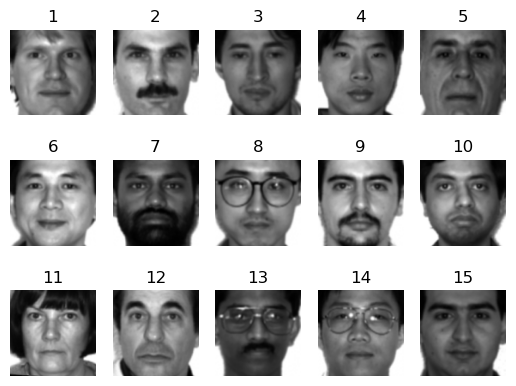

In [ ]:
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#读取Yale图片数据(15人，每人11张照片)
rootpath='../Data'  
X=[]             #存储图片数据
for person in range(15):
    for num in range(11):
        path=rootpath+'/'+str(person+1)+'/s'+str(num+1)+'.bmp'
        img=Image.open(path)
        X.append(np.array(img).reshape(-1))
X=np.array(X)

#显示降维前的图片(只显示每个人的第一个图片)
for i in range(3):
    for j in range(5):
        plt.subplot(3,5,i*5+j+1)
        plt.imshow(X[(i*5+j)*11,:].reshape(100,100),cmap='gray')
        plt.axis('off')
        plt.title('%d'%(i*5+j+1))
plt.show()


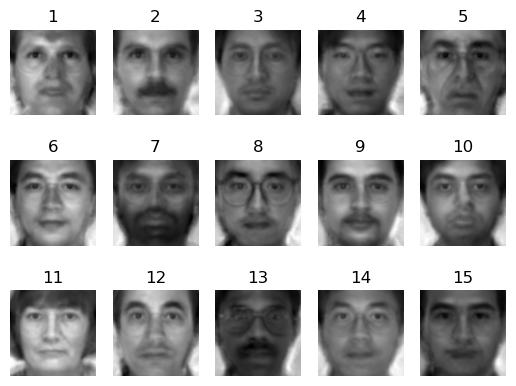

In [6]:
class PCA:
    def __init__(self, d):
        """
        PCA算法
        参数：
        d: 降维后的维度
        """
        self.d = d

    def fit_transform(self, X):
        """降维"""
        # 对样本中心化
        X = X - np.mean(X, axis=0)
        # 计算协方差矩阵
        cov = np.dot(X.T, X) #(n×n)
        # 对协方差进行特征值分解
        λ,W = np.linalg.eigh(cov)
        # 将特征值从大到小排序
        idx = np.argsort(-λ)
        λ = λ[idx]
        W = W[:, idx]
        # 选择前d个特征向量
        λ_star = λ[:self.d]
        W_star = W[:, :self.d]
        # 计算降维后的样本Z
        Z = np.dot(X, W_star).T
        return Z, W_star
    
if __name__ == '__main__':
    # 降维
    pca = PCA(20)
    X_new,W = pca.fit_transform(X)
    # 重构
    X_reverse = np.dot(W, X_new).T + np.mean(X, axis=0)
    # 可视化降维后的图片
    for i in range(3):
        for j in range(5):
            plt.subplot(3,5,i*5+j+1)
            plt.imshow(X_reverse[(i*5+j)*11,:].reshape(100,100),cmap='gray')
            plt.axis('off')
            plt.title('%d'%(i*5+j+1))
    plt.show()